# Thesis Experiment: SAC-Based Gamma Controller (Weekly Rebalancing)
**Setup:** 7-Day Rebalancing Frequency | SAC replaces PPO | Multi-seed evaluation

**Perubahan utama dari versi PPO:**
- `PPO` → `SAC` (Soft Actor-Critic) — off-policy, lebih efisien dengan data terbatas
- Tambah `EquallyWeighted` & `ClassicalMarkowitz` sebagai benchmark
- Multi-seed training (3 seeds) untuk credibility statistik
- Reward normalization untuk stabilitas training
- Tambah `Calmar Ratio` pada metrik evaluasi

# 📝 Experiment Improvement Plan & Thesis Notes

This section documents critical improvements suggested for the thesis credibility and model performance.

### 🔴 Critical for Thesis
1.  **Multi-Seed Statistical Credibility**: (✅ UPDATED) Changed `SEEDS` to `[42, 123, 77]` to ensure results are statistically representative.
2.  **Statistical Significance Tests**: (✅ UPDATED) Implement t-test or Diebold-Mariano test to validate if SAC-Net's performance is significantly better than baselines.
3.  **Reward Normalization Stability**: (🛠️ BUG FIX) Rename `self._rew_var` to `self._rew_M2` to accurately reflect Welford's algorithm and ensure normalization stability.

### 🟢 Immediate Improvements
*   **Increased Training Steps**: (✅ UPDATED) Raised `TRAIN_STEPS` from 5,000 to 50,000 for better policy convergence.

### 💡 Potential Thesis Contributions
*   **Market Regime Analysis**: Analyze the correlation between SAC-chosen Gamma and market conditions (volatility, momentum). This provides insight into the agent's behavior and strengthens the research narrative.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces

# === PERUBAHAN UTAMA: Import SAC, bukan PPO ===
from stable_baselines3 import SAC, PPO          # PPO tetap untuk perbandingan
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEEDS = [42]  # Kembalikan ke [42] sebelum final run
print('Libraries loaded. SAC mode active.')
print(f'Training seeds: {SEEDS}')

Libraries loaded. SAC mode active.
Training seeds: [42]


## Phase 1: Data Preparation

In [21]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    
    split_idx = int(len(df) * train_split)
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]
    return train_df, test_df, assets

ret_old, ret_test, assets = load_and_split(file_data)

SET_WINDOW    = 30
SET_REBALANCE = 7
print(f'Data loaded. Assets ({len(assets)}): {assets}')
print(f'Training period : {ret_old.index[0].date()} – {ret_old.index[-1].date()} ({len(ret_old)} days)')
print(f'Test period (30%) : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')

USDT removed from assets.
Data loaded. Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training period : 2017-09-15 – 2019-03-02 (534 days)
Test period (30%) : 2019-03-03 – 2019-10-17 (229 days)


## Phase 2: Core Functions

In [22]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def get_centrality_weights(returns_window, gamma=1.0):
    T, N = returns_window.shape
    mu    = returns_window.mean().values
    sigma = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    fun  = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    res  = minimize(fun, np.ones(N)/N, method='SLSQP', bounds=bnds, constraints=cons)
    return res.x if res.success else np.ones(N)/N


def get_network_metrics(returns_window):
    T, N = returns_window.shape
    corr_f  = apply_rmt_filter(returns_window)
    density = np.sum(np.abs(corr_f) > 0.1) / (N * N)
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return np.array([
        np.std(cent_vec)  * 10,
        np.mean(cent_vec) * 10,
        mst_dist          * 0.1,
        np.max(cent_vec),
        density
    ], dtype=np.float32)


def calculate_metrics(returns_series):
    """Metrik performa portfolio — termasuk Calmar Ratio."""
    total_ret = (1 + returns_series).prod() - 1
    ann_ret   = (1 + total_ret) ** (252 / len(returns_series)) - 1
    ann_vol   = returns_series.std() * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    peak       = cumulative.cummax()
    drawdown   = (cumulative - peak) / peak
    max_dd     = drawdown.min()
    # Calmar = Ann.Return / |Max Drawdown|
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return {
        'Total Return'   : total_ret,
        'Ann. Return'    : ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio'   : sharpe,
        'Calmar Ratio'   : calmar,
        'Max Drawdown'   : max_dd,
    }

print('Core functions defined.')

Core functions defined.


In [23]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()


class EquallyWeighted(PortfolioStrategy):
    """Benchmark 1: 1/N Equal Weight."""
    def compute_weights(self, rw):
        return np.ones(rw.shape[1]) / rw.shape[1]


class ClassicalMarkowitz(PortfolioStrategy):
    """Benchmark 2: Minimum Variance (no network regularization)."""
    def compute_weights(self, rw):
        cov = rw.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)


class NetworkMarkowitz(PortfolioStrategy):
    """NW baseline: fixed gamma."""
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, rw):
        return get_centrality_weights(rw, self.gamma)


# === PERUBAHAN: RLNetworkMarkowitz sekarang support SAC dan PPO ===
class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based gamma controller.
    algo: 'sac' atau 'ppo' — menentukan loader yang digunakan.
    """
    def __init__(self, name, model_path, algo='sac',
                 gamma_center=1.0, gamma_range=1.0):
        super().__init__(name)
        if algo == 'sac':
            self.model = SAC.load(model_path)
        else:
            self.model = PPO.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range  = gamma_range

    def compute_weights(self, rw):
        nw_feat = get_network_metrics(rw)
        short_ret  = rw.iloc[-5:].mean().mean()
        long_ret   = rw.mean().mean()
        momentum   = short_ret - long_ret
        recent_vol = rw.iloc[-5:].std().mean()
        mkt_feat = np.array(
            [short_ret*100, momentum*100, recent_vol*100, 0.0],
            dtype=np.float32
        )
        obs = np.nan_to_num(np.concatenate([nw_feat, mkt_feat]))
        action, _ = self.model.predict(obs, deterministic=True)
        self.last_gamma = float(np.clip(action[0], -5.0, 5.0)) + self.gamma_center
        return get_centrality_weights(rw, gamma=self.last_gamma)

print('Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).')

Strategy classes defined (EquallyWeighted, ClassicalMarkowitz, NetworkMarkowitz, RLNetworkMarkowitz).


## Phase 3: Environment & Precompute

**Perubahan vs versi PPO:**
- `action_space`: tetap `[-1, 1]` — SAC secara internal menggunakan `tanh` squashing, jadi batas ini konsisten
- Tambah `reward_normalization`: running mean/std agar scale reward stabil selama training SAC
- Mode reward baru: `'sharpe_incremental'` — lebih informatif dari `excess_nw`

In [24]:
def precompute_env_data(returns_data, window_size=30):
    n_steps = len(returns_data) - window_size
    obs_cache, opt_cache, baseline_ret_cache = {}, {}, {}
    print(f'Precomputing {n_steps} window positions...')
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        nw_feat   = get_network_metrics(win)
        short_ret = win.iloc[-5:].mean().mean()
        long_ret  = win.mean().mean()
        mkt_feat  = np.array(
            [short_ret*100, (short_ret-long_ret)*100, win.iloc[-5:].std().mean()*100, 0.0],
            dtype=np.float32
        )
        obs_cache[i] = (nw_feat, mkt_feat)
        mu    = win.mean().values
        sigma = win.std().values
        corr_f = apply_rmt_filter(win)
        cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        mst = nx.minimum_spanning_tree(nx.from_numpy_array(dist_mat))
        try:
            cent = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([cent[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        opt_cache[i] = (cov_f, cent_vec, mu)
        w_base = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_base, returns_data.iloc[i].values)
    print(f'Precomputation done! ({n_steps} positions cached)')
    return obs_cache, opt_cache, baseline_ret_cache


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    N   = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    res = minimize(fun, np.ones(N)/N, method='SLSQP',
                   bounds=tuple((0, 0.4) for _ in range(N)), constraints=cons)
    return res.x if res.success else np.ones(N)/N

print('Precompute functions defined.')

Precompute functions defined.


In [25]:
class GammaPortfolioEnvFast(gym.Env):
    """
    Environment dengan gamma centering + reward normalization.

    Perbedaan dari versi PPO:
    - Reward normalization (running stats) → lebih stabil untuk SAC
    - Mode 'sharpe_incremental': reward = rolling_sharpe - benchmark_sharpe
    - action_space diperluas ke [-5, 5]; SAC menggunakan tanh squashing secara internal
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None, window_size=30,
                 reward_mode='excess_nw',
                 gamma_center=1.0, gamma_range=1.0,
                 normalize_reward=True):
        super().__init__()
        self.data               = returns_data
        self.obs_cache          = obs_cache
        self.opt_cache          = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size        = window_size
        self.reward_mode        = reward_mode
        self.gamma_center       = gamma_center
        self.gamma_range        = gamma_range
        self.normalize_reward   = normalize_reward
        self.current_step       = window_size
        self.port_val           = 1.0
        self.peak_val           = 1.0
        # Running reward stats untuk normalisasi
        self._rew_mean = 0.0
        self._rew_M2  = 1.0
        self._rew_count = 0
        # Recent returns buffer untuk sharpe_incremental
        self._ret_buffer = []
        # Action & observation space — sama dengan versi PPO
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)

    def _action_to_gamma(self, action):
        return float(np.clip(action, -5.0, 5.0)) + self.gamma_center

    def _get_obs(self):
        nw_feat, mkt_feat = self.obs_cache[self.current_step]
        mf = mkt_feat.copy()
        mf[3] = self.port_val - 1
        return np.concatenate([nw_feat, mf])

    def _normalize_reward(self, r):
        """Welford online normalization."""
        if not self.normalize_reward:
            return r
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        self._rew_M2  += delta * (r - self._rew_mean)
        std = max(np.sqrt(self._rew_M2 / self._rew_count), 1e-6)
        return np.clip(r / std, -10.0, 10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val     = 1.0
        self.peak_val     = 1.0
        self._ret_buffer  = []
        # Reset running reward stats per episode
        self._rew_mean = 0.0
        self._rew_M2   = 1.0
        self._rew_count = 0
        return self._get_obs(), {}

    def step(self, action):
        gamma    = self._action_to_gamma(action[0])
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        nw_ret   = self.baseline_ret_cache.get(self.current_step,
                        self.data.iloc[self.current_step].mean())
        self._ret_buffer.append(port_ret)
        if len(self._ret_buffer) > 20:
            self._ret_buffer.pop(0)

        # ── Reward computation ────────────────────────────────────────────
        if self.reward_mode == 'excess_nw':
            raw = (port_ret - nw_ret) * 100

        elif self.reward_mode == 'sharpe_incremental':
            # Rolling 20-day Sharpe selisih vs NW baseline
            if len(self._ret_buffer) >= 5:
                buf = np.array(self._ret_buffer)
                port_sharpe = buf.mean() / (buf.std() + 1e-8)
            else:
                port_sharpe = 0.0
            raw = port_sharpe * 10   # scale

        elif self.reward_mode == 'risk_adjusted_excess':
            excess     = (port_ret - nw_ret) * 100
            dd_penalty = min(abs(drawdown) * 10, 2.0)
            raw = excess - dd_penalty

        elif self.reward_mode == 'defensive':
            raw = (port_ret - 2.0 * abs(drawdown)) * 100

        elif self.reward_mode == 'total_return':
            # Performance-linked bonus: reward deviation only if return is positive
            exploration_signal = (port_ret * 100) * abs(gamma - self.gamma_center) * 0.1
            raw = port_ret * 100 + exploration_signal

        else:  # sharpe-like default
            std = self.data.iloc[
                self.current_step - self.window_size : self.current_step
            ].values.std()
            raw = port_ret / (std + 1e-6) * 10

        reward = self._normalize_reward(raw)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}


print('GammaPortfolioEnvFast defined (with reward normalization).')

GammaPortfolioEnvFast defined (with reward normalization).


## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [26]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets, dates, weights_history, gamma_history = [], [], [], []
    current_weights = None
    current_gamma   = 1.0
    print(f'Processing {strategy.name} (Freq: {rebalance_freq} days)...')
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df       = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma   = getattr(strategy, 'last_gamma', 1.0)
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    ret_series  = pd.Series(rets, index=dates, name=strategy.name)
    wts_df      = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series

print('Backtest engine defined.')

Backtest engine defined.


## Phase 5: SAC Training (Multi-Seed)

**Perubahan utama vs PPO:**

| Parameter | PPO (lama) | SAC (baru) | Alasan |
|-----------|-----------|-----------|--------|
| Algorithm | On-policy | Off-policy | SAC reuse data lewat replay buffer |
| `n_steps` | 2048 (rollout buffer) | — (tidak ada) | SAC update setiap step |
| `buffer_size` | — | 50000 | SAC menyimpan semua pengalaman |
| `ent_coef` | 0.01 (manual) | `'auto'` | SAC tuning entropy otomatis |
| `batch_size` | 128 | 256 | SAC lebih stabil dengan batch lebih besar |
| Training seeds | 1 | 3 | Credibility statistik |


In [27]:
# Precompute (1x, shared oleh semua seeds)
obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(
    ret_old, window_size=SET_WINDOW
)

GAMMA_CENTER = 1.0
GAMMA_RANGE  = 5.0   # Diperluas agar lebih volatil (gamma ∈ [-4.0, 6.0])
TRAIN_STEPS  = 15000  # uji kode dulu

# ================================================================
# SAC Hyperparameters
# Catatan untuk tesis: SAC adalah off-policy actor-critic dengan
# maximum entropy framework. Tidak memerlukan n_steps/n_epochs
# seperti PPO karena update dilakukan per-step dari replay buffer.
# ================================================================
sac_kwargs = dict(
    policy          = 'MlpPolicy',
    verbose         = 0,              # set 1 untuk melihat log
    learning_rate   = 3e-4,
    buffer_size     = 50_000,         # replay buffer besar — menampung semua training steps
    learning_starts = 1_000,          # exploration murni dulu sebelum update
    batch_size      = 256,            # lebih besar dari PPO untuk stabilitas
    tau             = 0.005,          # soft update target network
    gamma           = 0.99,
    train_freq      = 1,              # update setiap 1 step
    gradient_steps  = 1,
    ent_coef        = 'auto',         # SAC mengatur secara otomatis
    target_entropy  = 'auto',
    use_sde         = False,
    policy_kwargs   = dict(net_arch=[64, 64]),
)

print(f'SAC config ready. Training {len(SEEDS)} seeds × 2 reward modes = {len(SEEDS)*2} models')
print(f'Gamma range: [{GAMMA_CENTER - GAMMA_RANGE}, {GAMMA_CENTER + GAMMA_RANGE}]')

Precomputing 504 window positions...
Precomputation done! (504 positions cached)
SAC config ready. Training 1 seeds × 2 reward modes = 2 models
Gamma range: [-4.0, 6.0]


In [28]:
reward_modes = {
    'sharpe_incremental': 'SAC-Net (Sharpe Incr)',
    'total_return'    : 'SAC-Net (Total Return)',
}

trained_models = {}   # {(mode, seed): model}

for mode, label in reward_modes.items():
    for seed in SEEDS:
        model_name = f'sac_{mode}_seed{seed}'
        print(f'\nTraining [{label}] seed={seed}...')

        env = GammaPortfolioEnvFast(
            ret_old, obs_cache, opt_cache, baseline_ret_cache,
            window_size=SET_WINDOW, reward_mode=mode,
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE,
            normalize_reward=True
        )

        model = SAC(env=env, seed=seed, **sac_kwargs)
        model.learn(total_timesteps=TRAIN_STEPS, progress_bar=True)
        model.save(model_name)

        trained_models[(mode, seed)] = model_name
        print(f'  Saved: {model_name}.zip')

print('\n=== All SAC models trained ===')


Output()


Training [SAC-Net (Sharpe Incr)] seed=42...


Output()

  Saved: sac_sharpe_incremental_seed42.zip

Training [SAC-Net (Total Return)] seed=42...


  Saved: sac_total_return_seed42.zip

=== All SAC models trained ===


## Phase 6: In-Sample Backtest (Training Data)

Setiap SAC model dibacktest, kemudian diambil **mean ± std** dari 3 seeds untuk setiap reward mode.

In [29]:
COLORS = {
    'Equal Weight'           : 'dimgray',
    'Classical Markowitz'    : 'slategray',
    'NW (Gamma=1.0)'         : 'steelblue',
    'NW (Gamma=0.0)'         : 'lightblue',
    'SAC-Net (Excess NW)'    : 'crimson',
    'SAC-Net (Sharpe Incr)'  : 'darkorange',
    'SAC-Net (Total Return)': 'purple',
    'BTC (Buy & Hold)'       : 'black',
}

def run_multiseed_backtest(mode, label, data, seeds=SEEDS, period='train'):
    """
    Jalankan backtest untuk semua seed suatu mode.
    Return: dict seed -> (ret_series, gamma_series)
    """
    seed_results = {}
    for seed in seeds:
        model_path = f'sac_{mode}_seed{seed}'
        strat = RLNetworkMarkowitz(
            f'{label} [s{seed}]', model_path, algo='sac',
            gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
        )
        ret, _, gamma = run_backtest_with_frequency(
            strat, data, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        seed_results[seed] = (ret, gamma)
    return seed_results


def aggregate_seed_results(seed_results):
    """
    Hitung mean return series dari beberapa seeds.
    Return: mean_series, std_series
    """
    all_rets = pd.DataFrame({s: r for s, (r, _) in seed_results.items()})
    return all_rets.mean(axis=1), all_rets.std(axis=1)


print('Multi-seed backtest utilities defined.')

Multi-seed backtest utilities defined.


In [30]:
# ── Baseline strategies ───────────────────────────────────────────────────
baseline_strategies = [
    EquallyWeighted('Equal Weight'),
    ClassicalMarkowitz('Classical Markowitz'),
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
]

results_train = {}
for s in baseline_strategies:
    ret, _, _ = run_backtest_with_frequency(
        s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_train[s.name] = ret

if 'BTC' in ret_old.columns:
    results_train['BTC (Buy & Hold)'] = ret_old['BTC'].iloc[SET_WINDOW:]

# ── SAC strategies (multi-seed) ───────────────────────────────────────────
sac_seed_results_train = {}
sac_gamma_train        = {}

for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_old)
    sac_seed_results_train[(mode, label)] = sr
    mean_ret, std_ret = aggregate_seed_results(sr)
    mean_ret.name = label
    results_train[label] = mean_ret
    # Simpan gamma dari seed pertama sebagai representatif
    sac_gamma_train[label] = sr[SEEDS[0]][1]

print('In-sample backtest complete.')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s42] (Freq: 7 days)...
In-sample backtest complete.


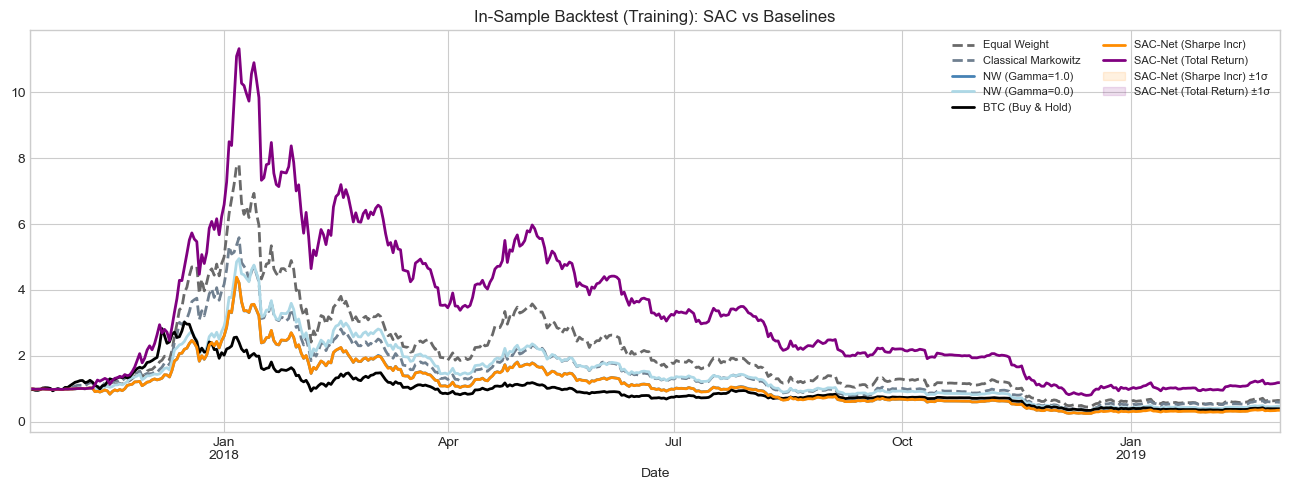

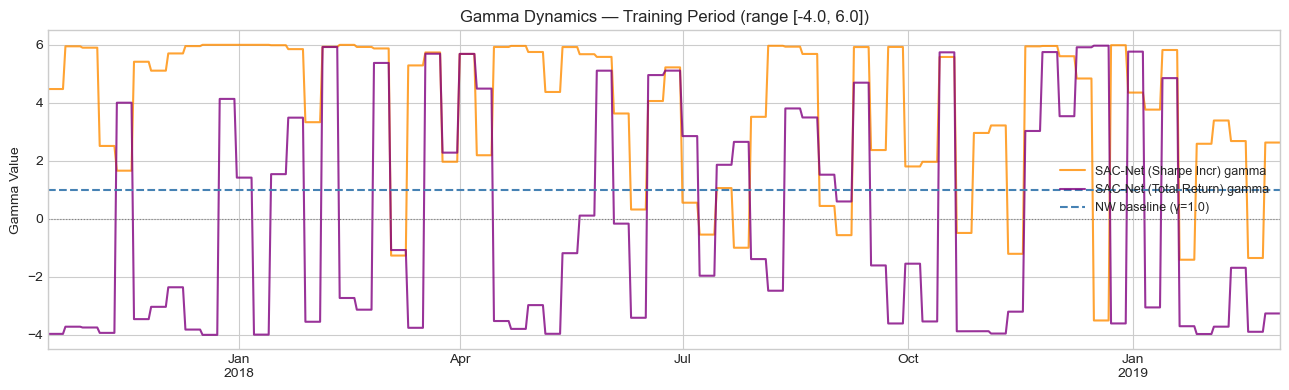

In [31]:
# ── Plot 1: Cumulative Returns (Training) ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results_train.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'purple'),
        linewidth=2.0,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )
# Tambah confidence band untuk SAC
for mode, label in reward_modes.items():
    sr   = sac_seed_results_train[(mode, label)]
    mean_r, std_r = aggregate_seed_results(sr)
    cum_mean = (1 + mean_r).cumprod()
    cum_std  = std_r * np.sqrt(np.arange(1, len(std_r)+1))  # approx
    ax.fill_between(
        cum_mean.index,
        (cum_mean - cum_std).clip(lower=0),
        cum_mean + cum_std,
        alpha=0.12, color=COLORS.get(label, 'purple'), label=f'{label} ±1σ'
    )
ax.set_title('In-Sample Backtest (Training): SAC vs Baselines')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Plot 2: Gamma Dynamics (Training) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for label, g in sac_gamma_train.items():
    g.plot(ax=ax, label=f'{label} gamma', color=COLORS.get(label, 'purple'), alpha=0.8)
ax.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)')
ax.axhline(0.0, color='gray',      linestyle=':', linewidth=0.8)
ax.set_title(f'Gamma Dynamics — Training Period (range [{GAMMA_CENTER-GAMMA_RANGE}, {GAMMA_CENTER+GAMMA_RANGE}])')
ax.set_ylabel('Gamma Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
# ── Performance Metrics Table (Training) ─────────────────────────────────
stats_train = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_train.items()}
).T
stats_train.index.name = 'Strategy'

# Tambah kolom std Sharpe dari multi-seed
sharpe_std_train = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_train[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_train[label] = np.std(sharpe_per_seed)

stats_train['Sharpe Std (seeds)'] = pd.Series(sharpe_std_train)

# Simpan CSV
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)
stats_train.to_csv(os.path.join(csv_dir, 'sac_training_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_train.items()}).to_csv(
    os.path.join(csv_dir, 'sac_training_cumret.csv')
)

print('=== In-Sample Performance Metrics (Training) ===')
print(stats_train.round(4).to_string())
print(f'\nCSV saved to: {csv_dir}/')

=== In-Sample Performance Metrics (Training) ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                        
Equal Weight                 -0.3509      -0.1944           0.8747       -0.2222       -0.2063       -0.9421                 NaN
Classical Markowitz          -0.4094      -0.2315           0.8426       -0.2747       -0.2472       -0.9367                 NaN
NW (Gamma=1.0)               -0.6291      -0.3910           0.8111       -0.4820       -0.4151       -0.9419                 NaN
NW (Gamma=0.0)               -0.5232      -0.3095           0.7861       -0.3937       -0.3325       -0.9310                 NaN
BTC (Buy & Hold)             -0.6028      -0.3698           0.7135       -0.5183       -0.4176       -0.8855                 NaN
SAC-Net (Sharpe Incr)        -0.6496      -0.408

## Phase 7: Weight Concentration Diagnostic (Training Data)

Processing NW (Gamma=1.0) (Freq: 7 days)...
=== Rata-rata Bobot NW (Gamma=1.0) — Training ===
BTC    0.2697
BNB    0.1587
XRP    0.1234
LTC    0.1057
ETH    0.0998
XLM    0.0878
TRX    0.0529
BCH    0.0528
EOS    0.0494


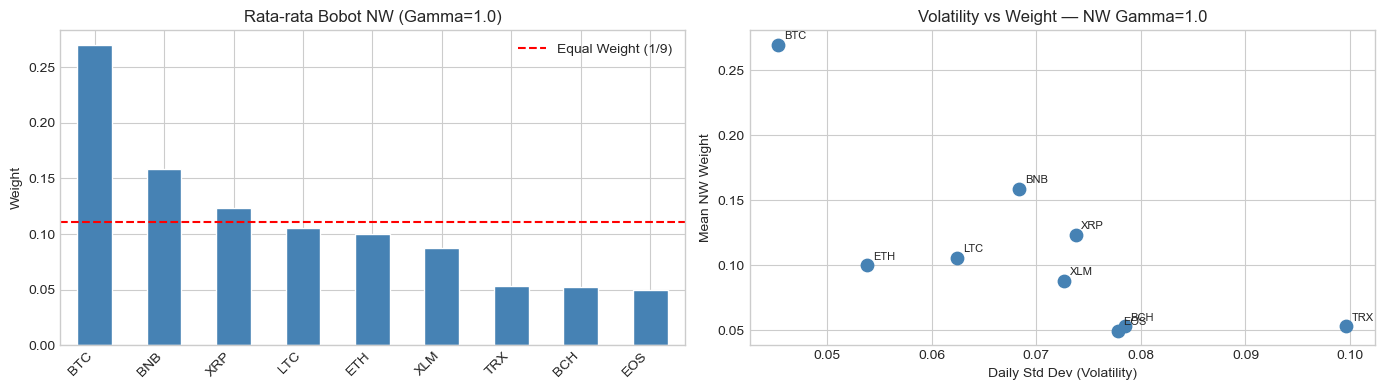


=== Days with Weight > 30% ===
BTC    273
ETH     56
BCH     35
BNB     35
LTC     28
XRP     28
XLM     14
EOS      7
TRX      7

=== Asset Stats vs Weight ===
     Mean Daily Return  Std (Volatility)  Mean Weight
BTC           0.000380          0.045336     0.269651
ETH          -0.001632          0.053869     0.099847
LTC           0.000308          0.062471     0.105665
BNB           0.003344          0.068372     0.158653
XLM           0.001402          0.072646     0.087757
XRP           0.000694          0.073774     0.123375
EOS           0.002045          0.077795     0.049399
BCH          -0.002990          0.078463     0.052774
TRX           0.004271          0.099642     0.052878


In [33]:
nw_strat = NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0)
_, nw_wts_train, _ = run_backtest_with_frequency(
    nw_strat, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
)

mean_wts = nw_wts_train.mean().sort_values(ascending=False)
print('=== Rata-rata Bobot NW (Gamma=1.0) — Training ===')
print(mean_wts.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart bobot
mean_wts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(1/len(assets), color='red', linestyle='--', label=f'Equal Weight (1/{len(assets)})')
axes[0].set_title('Rata-rata Bobot NW (Gamma=1.0)')
axes[0].set_ylabel('Weight')
axes[0].legend()
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Scatter volatilitas vs bobot
asset_stats = pd.DataFrame({
    'Mean Daily Return': ret_old.mean(),
    'Std (Volatility)' : ret_old.std(),
    'Mean Weight'      : mean_wts,
}).sort_values('Std (Volatility)')
axes[1].scatter(asset_stats['Std (Volatility)'], asset_stats['Mean Weight'],
                s=80, color='steelblue')
for idx, row in asset_stats.iterrows():
    axes[1].annotate(idx, (row['Std (Volatility)'], row['Mean Weight']),
                     textcoords='offset points', xytext=(4, 4), fontsize=8)
axes[1].set_xlabel('Daily Std Dev (Volatility)')
axes[1].set_ylabel('Mean NW Weight')
axes[1].set_title('Volatility vs Weight — NW Gamma=1.0')

plt.tight_layout()
plt.show()

dominant_days = (nw_wts_train > 0.30).sum()
print('\n=== Days with Weight > 30% ===')
print(dominant_days[dominant_days > 0].sort_values(ascending=False).to_string())
print('\n=== Asset Stats vs Weight ===')
print(asset_stats.round(6).to_string())

## Phase 8: Out-of-Sample Backtest (Validation Data 30%)

Evaluasi generalisasi model SAC pada data validasi (30% sisanya) yang **tidak pernah dilihat saat training**.

In [34]:
# ── Baseline OOS ─────────────────────────────────────────────────────────
results_test = {}
for s in baseline_strategies:
    s2 = s.__class__(s.name, **({'gamma': s.gamma} if isinstance(s, NetworkMarkowitz) else {}))
    ret, _, _ = run_backtest_with_frequency(
        s2, ret_test, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_test[s.name] = ret

if 'BTC' in ret_test.columns:
    results_test['BTC (Buy & Hold)'] = ret_test['BTC'].iloc[SET_WINDOW:]

# ── SAC OOS (multi-seed) ──────────────────────────────────────────────────
sac_seed_results_test = {}
sac_gamma_test        = {}

for mode, label in reward_modes.items():
    sr = run_multiseed_backtest(mode, label, ret_test)
    sac_seed_results_test[(mode, label)] = sr
    mean_ret, _ = aggregate_seed_results(sr)
    mean_ret.name = label
    results_test[label] = mean_ret
    sac_gamma_test[label] = sr[SEEDS[0]][1]

print('Out-of-sample backtest complete.')

Processing Equal Weight (Freq: 7 days)...
Processing Classical Markowitz (Freq: 7 days)...
Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing SAC-Net (Sharpe Incr) [s42] (Freq: 7 days)...
Processing SAC-Net (Total Return) [s42] (Freq: 7 days)...
Out-of-sample backtest complete.


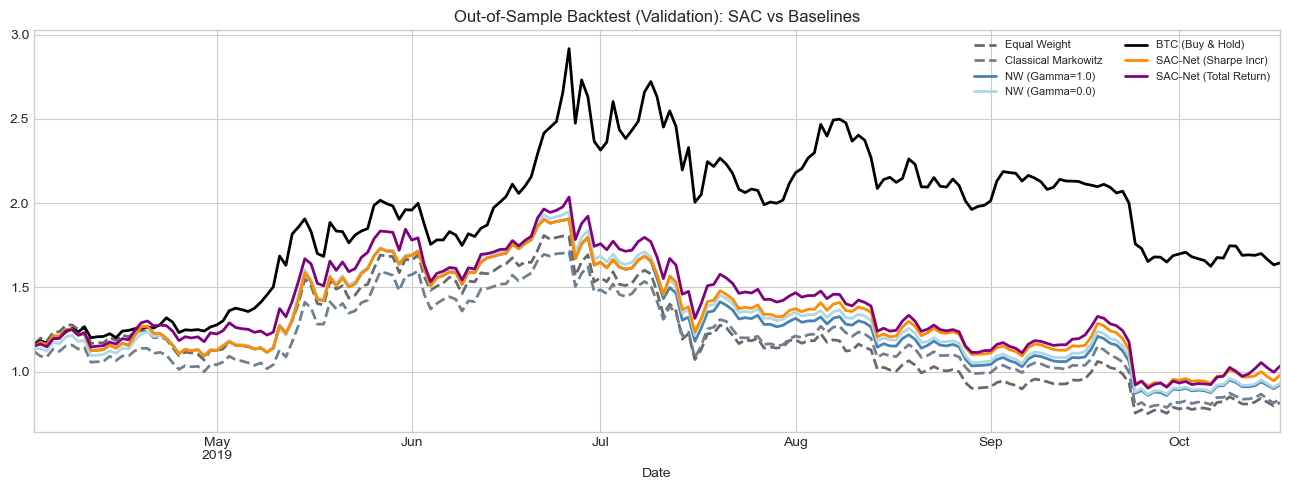

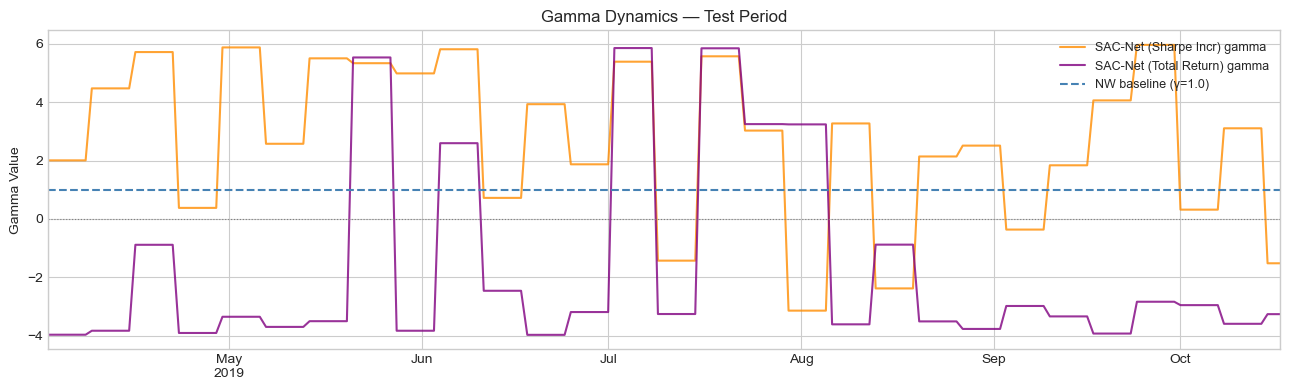

In [35]:
# ── Plot 1: Cumulative Returns (Validation) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for name, r in results_test.items():
    (1 + r).cumprod().plot(
        ax=ax, label=name,
        color=COLORS.get(name, 'purple'),
        linewidth=2.0,
        linestyle='--' if name in ['Equal Weight', 'Classical Markowitz'] else '-'
    )
# Confidence band
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    mean_r, std_r = aggregate_seed_results(sr)
    cum_mean = (1 + mean_r).cumprod()
    cum_std  = std_r * np.sqrt(np.arange(1, len(std_r)+1))
    ax.fill_between(
        cum_mean.index,
        (cum_mean - cum_std).clip(lower=0),
        cum_mean + cum_std,
        alpha=0.12, color=COLORS.get(label, 'purple')
    )
ax.set_title('Out-of-Sample Backtest (Validation): SAC vs Baselines')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── Plot 2: Gamma Dynamics (Validation) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for label, g in sac_gamma_test.items():
    g.plot(ax=ax, label=f'{label} gamma', color=COLORS.get(label, 'purple'), alpha=0.8)
ax.axhline(1.0, color='steelblue', linestyle='--', label='NW baseline (γ=1.0)')
ax.axhline(0.0, color='gray',      linestyle=':', linewidth=0.8)
ax.set_title(f'Gamma Dynamics — Test Period')
ax.set_ylabel('Gamma Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [36]:
# ── Performance Metrics Table (Test Period) ─────────────────────────────────────
stats_test = pd.DataFrame(
    {name: calculate_metrics(r) for name, r in results_test.items()}
).T
stats_test.index.name = 'Strategy'

sharpe_std_test = {}
for mode, label in reward_modes.items():
    sr = sac_seed_results_test[(mode, label)]
    sharpe_per_seed = [calculate_metrics(r)['Sharpe Ratio'] for r, _ in sr.values()]
    sharpe_std_test[label] = np.std(sharpe_per_seed)

stats_test['Sharpe Std (seeds)'] = pd.Series(sharpe_std_test)

# Simpan CSV
stats_test.to_csv(os.path.join(csv_dir, 'sac_test_metrics.csv'))
pd.DataFrame({n: (1+r).cumprod() for n, r in results_test.items()}).to_csv(
    os.path.join(csv_dir, 'sac_test_cumret.csv')
)

print('=== Out-of-Sample Performance Metrics (Validation) ===')
print(stats_test.round(4).to_string())
print(f'\nCSV saved to: {csv_dir}/')

=== Out-of-Sample Performance Metrics (Validation) ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown  Sharpe Std (seeds)
Strategy                                                                                                                        
Equal Weight                 -0.1844      -0.2275           0.6606       -0.3443       -0.3890       -0.5848                 NaN
Classical Markowitz          -0.1628      -0.2015           0.6321       -0.3188       -0.3722       -0.5414                 NaN
NW (Gamma=1.0)               -0.0791      -0.0991           0.6227       -0.1592       -0.1802       -0.5502                 NaN
NW (Gamma=0.0)               -0.0702      -0.0880           0.6216       -0.1416       -0.1580       -0.5571                 NaN
BTC (Buy & Hold)              0.6451       0.8783           0.6550        1.3410        1.9834       -0.4428                 NaN
SAC-Net (Sharpe Incr)        -0.0203      

## Phase 9: SAC vs PPO Comparison (Opsional)

Jika ingin membandingkan SAC dengan PPO versi sebelumnya secara langsung di tesis. 
Jalankan cell ini **setelah** memastikan model PPO (`ppo_nw_excess_v2.zip`) tersedia.

In [37]:
import os

ppo_models_exist = (
    os.path.exists('ppo_nw_excess_v2.zip') and
    os.path.exists('ppo_nw_riskadj_v2.zip')
)

if ppo_models_exist:
    print('PPO models found — running comparison...')
    ppo_strats = [
        RLNetworkMarkowitz('PPO-Net (Excess NW)',  'ppo_nw_excess_v2',  algo='ppo',
                           gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
        RLNetworkMarkowitz('PPO-Net (Risk-Adj)',   'ppo_nw_riskadj_v2', algo='ppo',
                           gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
    ]
    results_cmp = dict(results_test)  # copy hasil SAC
    for s in ppo_strats:
        ret, _, _ = run_backtest_with_frequency(
            s, ret_test, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
        )
        results_cmp[s.name] = ret

    stats_cmp = pd.DataFrame(
        {n: calculate_metrics(r) for n, r in results_cmp.items()}
    ).T
    print('\n=== SAC vs PPO — OOS Test ===')
    # Tampilkan hanya baris relevan
    highlight = [c for c in stats_cmp.index if 'SAC' in c or 'PPO' in c or 'NW' in c]
    print(stats_cmp.loc[highlight].round(4).to_string())
    stats_cmp.to_csv(os.path.join(csv_dir, 'sac_vs_ppo_comparison.csv'))
else:
    print('PPO model files tidak ditemukan.')
    print('Jalankan versi PPO terlebih dahulu, atau skip cell ini.')

PPO models found — running comparison...
Processing PPO-Net (Excess NW) (Freq: 7 days)...
Processing PPO-Net (Risk-Adj) (Freq: 7 days)...

=== SAC vs PPO — OOS Test ===
                        Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Calmar Ratio  Max Drawdown
NW (Gamma=1.0)               -0.0791      -0.0991           0.6227       -0.1592       -0.1802       -0.5502
NW (Gamma=0.0)               -0.0702      -0.0880           0.6216       -0.1416       -0.1580       -0.5571
SAC-Net (Sharpe Incr)        -0.0203      -0.0256           0.6292       -0.0407       -0.0491       -0.5215
SAC-Net (Total Return)        0.0324       0.0412           0.6517        0.0633        0.0740       -0.5576
PPO-Net (Excess NW)          -0.0748      -0.0938           0.6257       -0.1498       -0.1703       -0.5505
PPO-Net (Risk-Adj)           -0.0617      -0.0774           0.6211       -0.1246       -0.1398       -0.5540


## Phase 8: Statistical Significance Tests

To validate if the performance differences between strategies are statistically significant, we implement:
1.  **Paired T-Test**: Compares the mean daily returns.
2.  **Diebold-Mariano (DM) Test**: A standard test in forecasting to compare predictive accuracy (or in this case, the time series of returns).

In [38]:
from scipy import stats

def diebold_mariano_test(returns1, returns2, h=1):
    """
    Perform Diebold-Mariano test to compare two return series.
    h: forecast horizon (default 1 for daily returns)
    """
    d = np.array(returns1) - np.array(returns2)
    T = float(len(d))
    d_bar = np.mean(d)
    
    def autocovariance(xi, k):
        N = len(xi)
        xs = xi - np.mean(xi)
        if k == 0: return np.sum(xs**2) / N
        return np.sum(xs[k:] * xs[:-k]) / N

    var_d_bar = autocovariance(d, 0)
    for i in range(1, h):
        var_d_bar += 2 * autocovariance(d, i)
    var_d_bar /= T
    
    dm_stat = d_bar / np.sqrt(var_d_bar) if var_d_bar > 0 else 0.0
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# Comparison table
results_sig = []
target_strategies = [
    'SAC-Net (Excess NW)',
    'SAC-Net (Sharpe Incr)',
    'NW (Gamma=1.0)',
    'NW (Gamma=0.0)',
    'Equal Weight',
    'Classical Markowitz',
    'BTC (Buy & Hold)'
]

print("Evaluating statistical significance on Out-of-Sample returns...")
for i in range(len(target_strategies)):
    for j in range(i + 1, len(target_strategies)):
        s1, s2 = target_strategies[i], target_strategies[j]
        if s1 in results_test and s2 in results_test:
            r1, r2 = results_test[s1], results_test[s2]
            min_len = min(len(r1), len(r2))
            r1, r2 = r1.iloc[:min_len], r2.iloc[:min_len]
            
            t_stat, t_p = stats.ttest_rel(r1, r2)
            dm_stat, dm_p = diebold_mariano_test(r1, r2)
            
            results_sig.append({
                'Comparison': f"{s1} vs {s2}",
                'DM-Stat': dm_stat,
                'P-Value': dm_p,
                'Significant': 'Yes' if dm_p < 0.05 else 'No'
            })

df_sig = pd.DataFrame(results_sig)
print("\n=== Diebold-Mariano Test Results (OOS) ===")
print(df_sig.round(4).to_string(index=False))

# Save significance results
df_sig.to_csv(os.path.join(csv_dir, 'statistical_significance.csv'), index=False)


Evaluating statistical significance on Out-of-Sample returns...

=== Diebold-Mariano Test Results (OOS) ===
                                  Comparison  DM-Stat  P-Value Significant
     SAC-Net (Sharpe Incr) vs NW (Gamma=1.0)   1.5330   0.1253          No
     SAC-Net (Sharpe Incr) vs NW (Gamma=0.0)   0.8701   0.3842          No
       SAC-Net (Sharpe Incr) vs Equal Weight   1.3558   0.1752          No
SAC-Net (Sharpe Incr) vs Classical Markowitz   1.2564   0.2090          No
   SAC-Net (Sharpe Incr) vs BTC (Buy & Hold)  -1.5404   0.1235          No
            NW (Gamma=1.0) vs NW (Gamma=0.0)  -0.1888   0.8503          No
              NW (Gamma=1.0) vs Equal Weight   0.8463   0.3974          No
       NW (Gamma=1.0) vs Classical Markowitz   0.7223   0.4701          No
          NW (Gamma=1.0) vs BTC (Buy & Hold)  -1.7386   0.0821          No
              NW (Gamma=0.0) vs Equal Weight   0.8497   0.3955          No
       NW (Gamma=0.0) vs Classical Markowitz   0.9549   0.3396     